In [1]:
import os
import pandas as pd
from nyc_api import fetch_311

os.makedirs("../data/00_cache", exist_ok=True)

In [2]:
df = fetch_311()
df.head()

  fetched 50,000
  fetched 100,000
  fetched 150,000
  fetched 200,000
  fetched 250,000
  fetched 300,000
  fetched 350,000
  fetched 400,000
  fetched 450,000
  fetched 500,000
  fetched 550,000
  fetched 600,000
  fetched 650,000
  fetched 700,000
  fetched 750,000
  fetched 800,000
  fetched 850,000
  fetched 900,000
  fetched 950,000
  fetched 969,013
311: 969,013 records | 2026-04-26 to 2026-07-24


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,landmark,facility_type,taxi_pick_up_location,bridge_highway_name,bridge_highway_segment,road_ramp,taxi_company_borough,bridge_highway_direction,due_date
0,68796897,2026-04-26 19:13:07,2026-04-27T11:59:09.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HEAT,RESIDENTIAL BUILDING,10466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68793335,2026-04-26 19:13:09,2026-04-28T02:14:02.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,NO HEAT AND NO HOT WATER,RESIDENTIAL BUILDING,11419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68796835,2026-04-26 19:13:09,2026-05-08T06:23:34.000,HPD,Department of Housing Preservation and Develop...,GENERAL,COOKING GAS,SHUT-OFF,RESIDENTIAL BUILDING,11419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,68792266,2026-04-26 19:13:24,2026-04-27T18:55:50.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,68794727,2026-04-26 19:13:30,2026-04-27T03:15:45.000,NYPD,New York City Police Department,Abandoned Vehicle,With License Plate,NaN,Street/Sidewalk,11106,...,Car,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import numpy as np
import matplotlib.pyplot as plt

df["year_month"] = df["created_date"].dt.to_period("M")
df["year_week"] = df["created_date"].dt.to_period("W")

n_months = df["year_month"].nunique()
n_weeks = df["year_week"].nunique()
date_range = f"{df['created_date'].min().date()} – {df['created_date'].max().date()}"
print(f"Data spans {n_months} calendar months, {n_weeks} calendar weeks")

addr_total = df["incident_address"].dropna().value_counts()
addr_monthly_avg = addr_total / n_months
addr_weekly_avg = addr_total / n_weeks

type_total = df["complaint_type"].value_counts().head(20)
type_monthly_avg = type_total / n_months
type_weekly_avg = type_total / n_weeks

district_total = df["council_district"].dropna().value_counts().sort_values(ascending=False)
district_monthly_avg = district_total / n_months
district_weekly_avg = district_total / n_weeks


def plot_2x2(addr_counts, type_counts, district_counts, suptitle,
             addr_xlim=50, addr_xlabel="Complaints per address", count_label="Count"):
    district_pct = district_counts / district_counts.sum() * 100
    total_vol = addr_counts.sum()
    max_bin = min(float(addr_counts.max()), addr_xlim * 3)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{suptitle}  |  {date_range}", fontsize=13)

    ax = axes[0, 0]
    bins = np.arange(0.5, max_bin + 1.5, 1.0)
    ax.hist(addr_counts.values, bins=bins, edgecolor="white", linewidth=0.5)
    ax.set_xlim(0.5, addr_xlim + 0.5)
    ax.set_xlabel(addr_xlabel)
    ax.set_ylabel("# of addresses")
    ax.set_title("Incident distribution by address")

    ax = axes[0, 1]
    bucket_df = pd.DataFrame({
        "bucket": np.floor(addr_counts.values).astype(int),
        "vol": addr_counts.values,
    })
    bucket_vol = bucket_df.groupby("bucket")["vol"].sum() / total_vol * 100
    bucket_vol = bucket_vol[bucket_vol.index <= int(addr_xlim)]
    ax.bar(bucket_vol.index, bucket_vol.values, edgecolor="white", linewidth=0.5)
    ax.set_xlim(-0.5, addr_xlim + 0.5)
    ax.set_xlabel(addr_xlabel)
    ax.set_ylabel("% of total volume")
    ax.set_title("% of volume by complaints-per-address bucket")

    ax = axes[1, 0]
    ax.barh(type_counts.index[::-1], type_counts.values[::-1])
    ax.set_xlabel(count_label)
    ax.set_title("Top 20 complaint types")

    ax = axes[1, 1]
    x = range(len(district_counts))
    ax2 = ax.twinx()
    ax.bar(x, district_counts.values, alpha=0.8, label=count_label)
    ax2.plot(x, district_pct.values, color="tomato", marker=".", markersize=4, linewidth=1, label="% of total")
    ax.set_xticks(list(x))
    ax.set_xticklabels(district_counts.index, rotation=90, fontsize=7)
    ax.set_ylabel(count_label)
    ax2.set_ylabel("% of total")
    ax.set_title("Complaints by council district")
    ax.legend(ax.containers[:1] + ax2.lines[:1], [count_label, "% of total"], loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

Data spans 4 calendar months, 14 calendar weeks


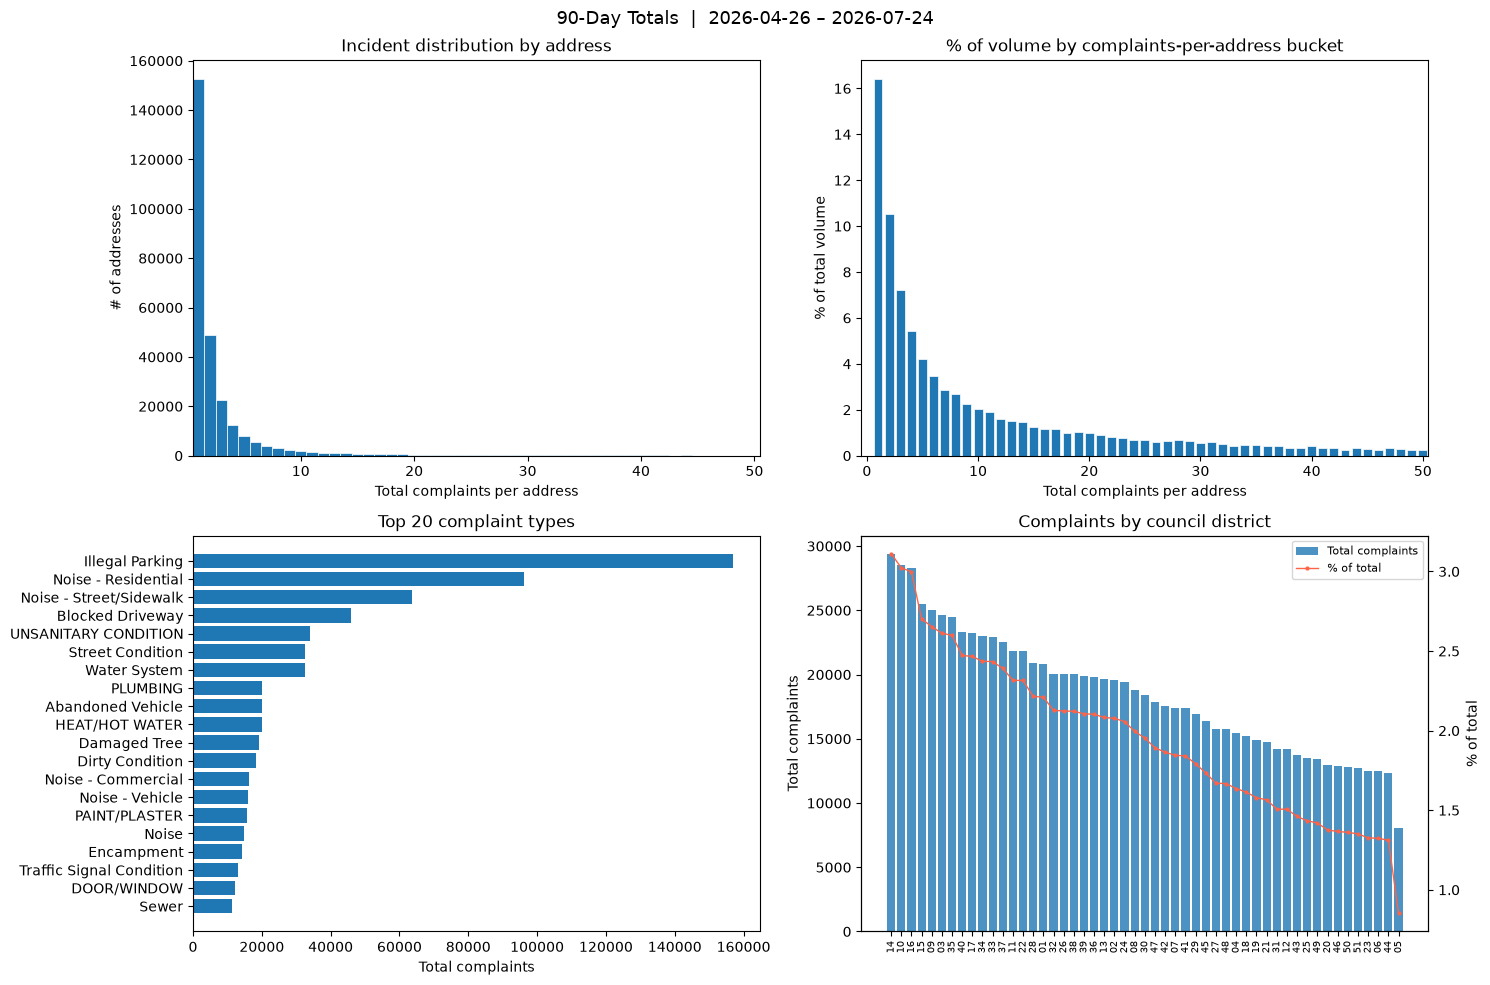

In [4]:
plot_2x2(addr_total, type_total, district_total,
         "90-Day Totals", addr_xlim=50,
         addr_xlabel="Total complaints per address", count_label="Total complaints")

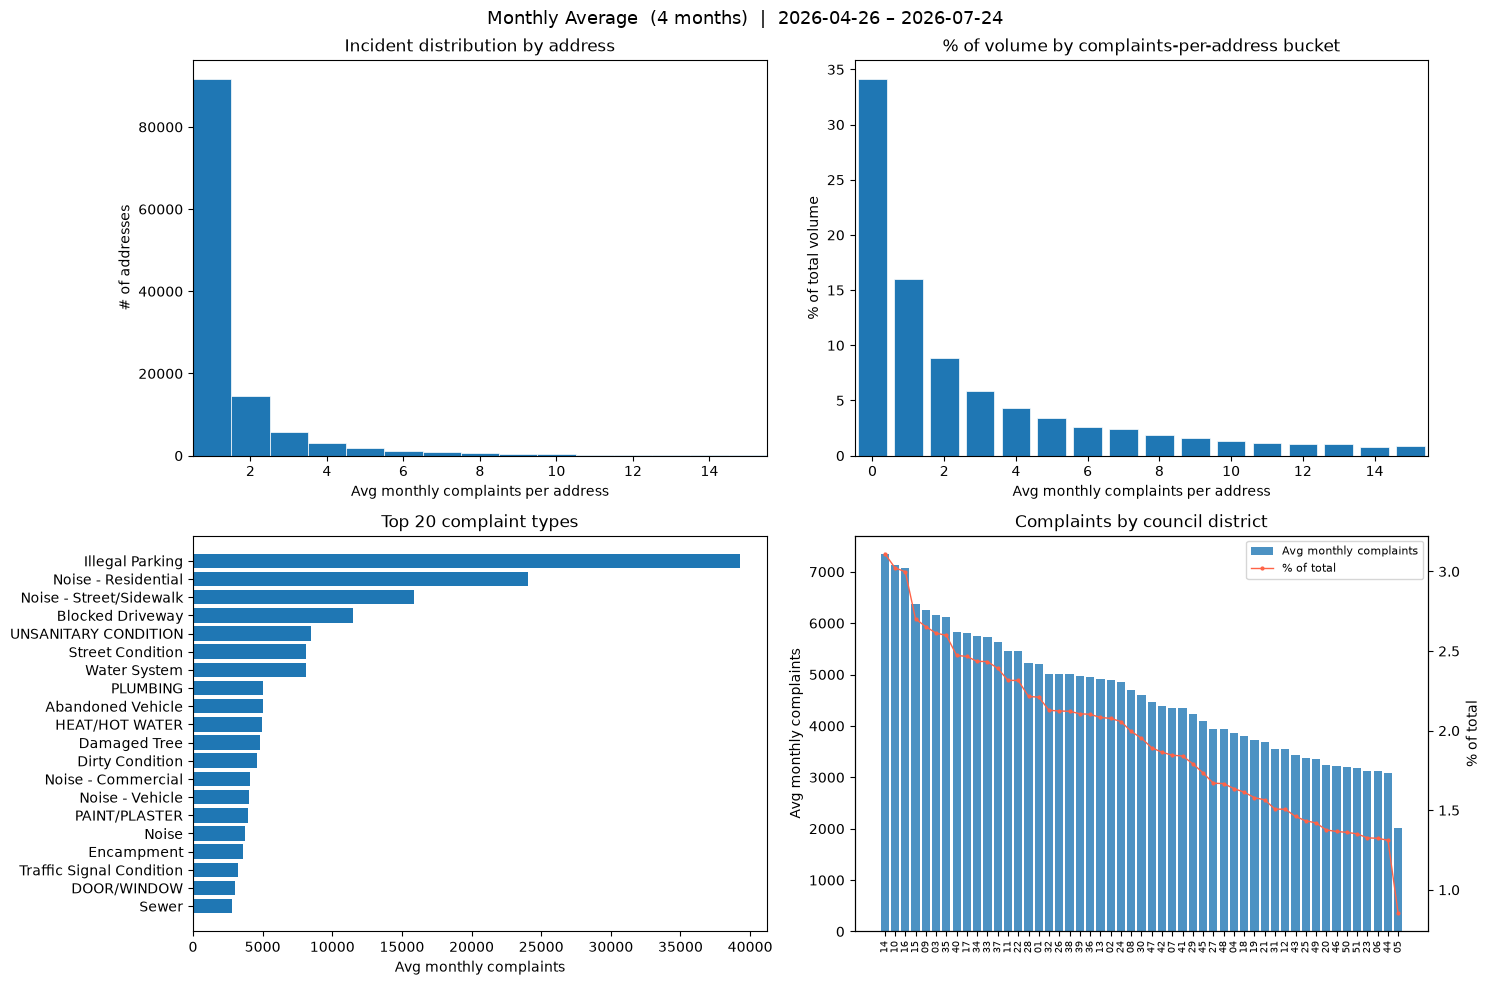

In [5]:
plot_2x2(addr_monthly_avg, type_monthly_avg, district_monthly_avg,
         f"Monthly Average  ({n_months} months)", addr_xlim=15,
         addr_xlabel="Avg monthly complaints per address", count_label="Avg monthly complaints")

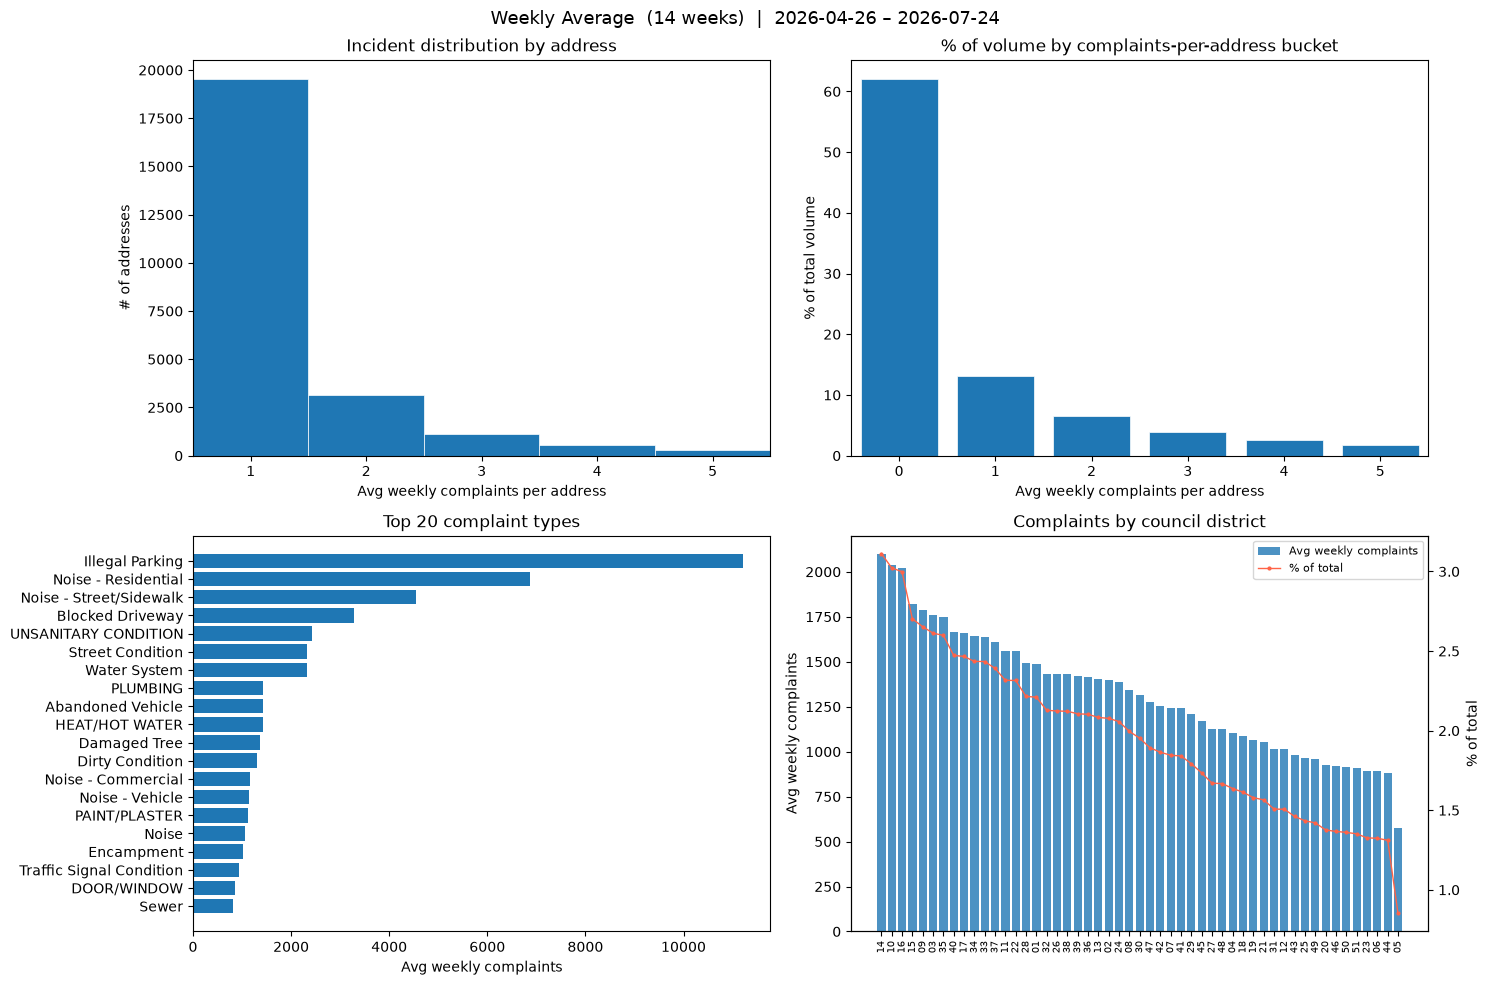

In [6]:
plot_2x2(addr_weekly_avg, type_weekly_avg, district_weekly_avg,
         f"Weekly Average  ({n_weeks} weeks)", addr_xlim=5,
         addr_xlabel="Avg weekly complaints per address", count_label="Avg weekly complaints")

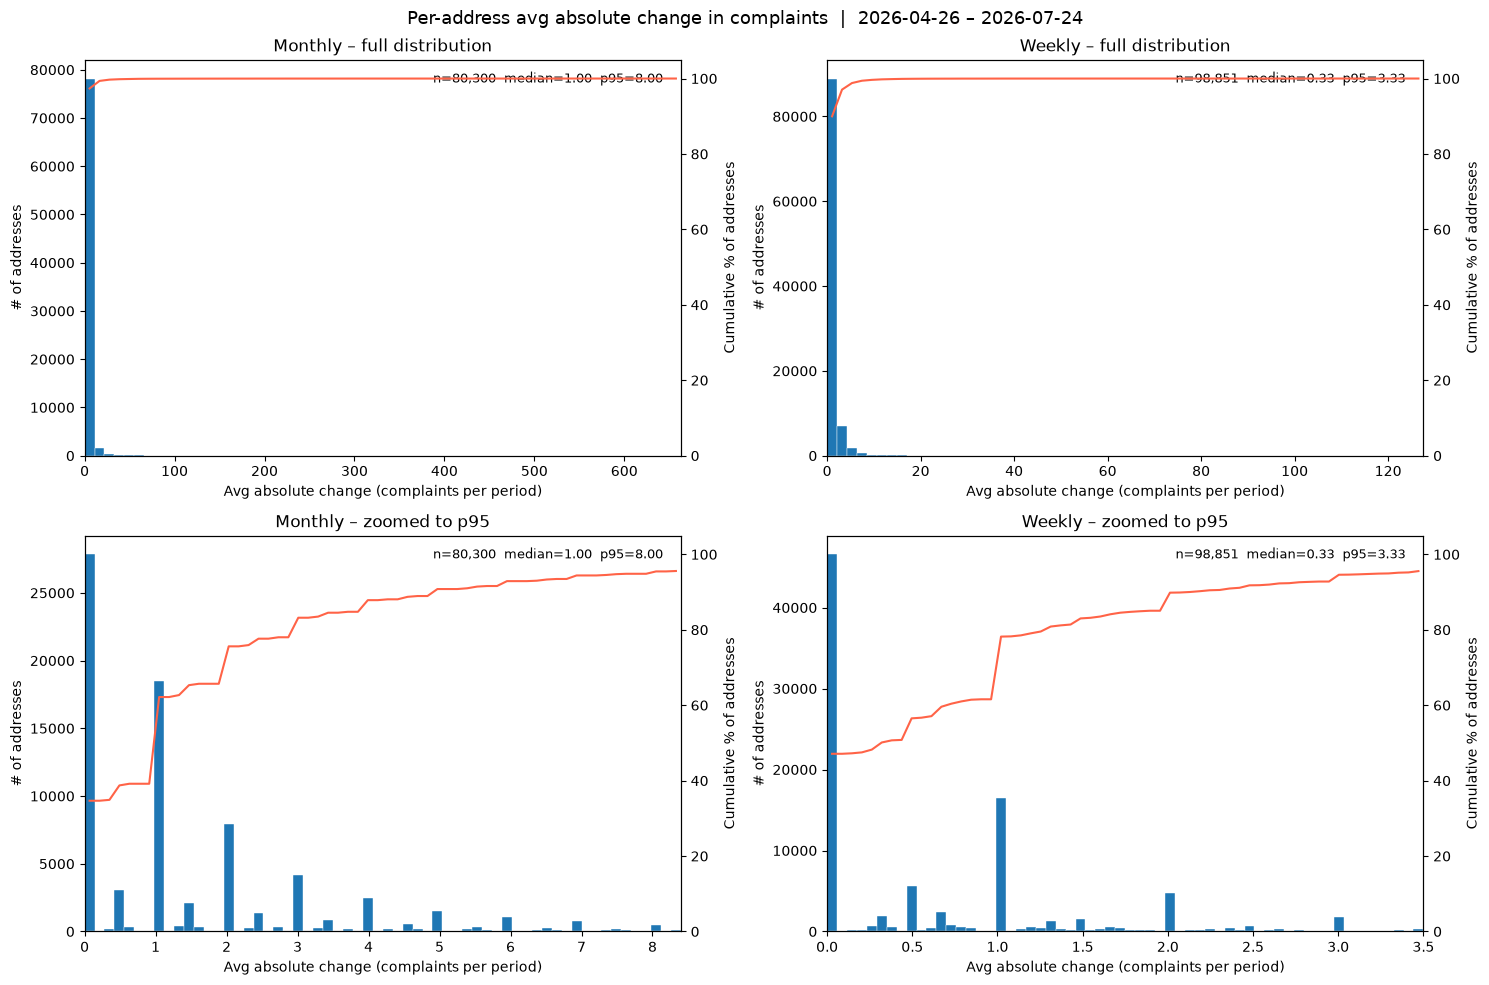

In [7]:
addr_by_month = (
    df.dropna(subset=["incident_address"])
    .groupby(["incident_address", "year_month"])
    .size()
    .reset_index(name="count")
    .sort_values(["incident_address", "year_month"])
)
addr_by_month["abs_change"] = addr_by_month.groupby("incident_address")["count"].diff().abs()
avg_monthly_abs = (
    addr_by_month.dropna(subset=["abs_change"])
    .groupby("incident_address")["abs_change"].mean()
)

addr_by_week = (
    df.dropna(subset=["incident_address"])
    .groupby(["incident_address", "year_week"])
    .size()
    .reset_index(name="count")
    .sort_values(["incident_address", "year_week"])
)
addr_by_week["abs_change"] = addr_by_week.groupby("incident_address")["count"].diff().abs()
avg_weekly_abs = (
    addr_by_week.dropna(subset=["abs_change"])
    .groupby("incident_address")["abs_change"].mean()
)


def plot_change_dist(ax, vals, title, xlim_max=None):
    n = len(vals)
    b_max = vals.max() if xlim_max is None else xlim_max
    bins = np.linspace(0, b_max * 1.05, 61)
    counts, edges = np.histogram(vals, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    width = edges[1] - edges[0]
    cumulative_pct = np.cumsum(counts) / n * 100

    ax.bar(centers, counts, width=width, edgecolor="white", linewidth=0.3)
    ax.set_xlim(0, b_max * 1.05)
    ax.set_xlabel("Avg absolute change (complaints per period)")
    ax.set_ylabel("# of addresses")
    ax.set_title(title)

    ax2 = ax.twinx()
    ax2.plot(centers, cumulative_pct, color="tomato", linewidth=1.5)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Cumulative % of addresses")

    ax.annotate(
        f"n={n:,}  median={np.median(vals):.2f}  p95={np.percentile(vals, 95):.2f}",
        xy=(0.97, 0.97), xycoords="axes fraction", ha="right", va="top", fontsize=9,
    )


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f"Per-address avg absolute change in complaints  |  {date_range}", fontsize=13)

for col, (changes, label) in enumerate([
    (avg_monthly_abs, "Monthly"),
    (avg_weekly_abs, "Weekly"),
]):
    p95 = np.percentile(changes.values, 95)
    plot_change_dist(axes[0, col], changes.values, f"{label} – full distribution")
    plot_change_dist(axes[1, col], changes.values, f"{label} – zoomed to p95", xlim_max=p95)

plt.tight_layout()
plt.show()

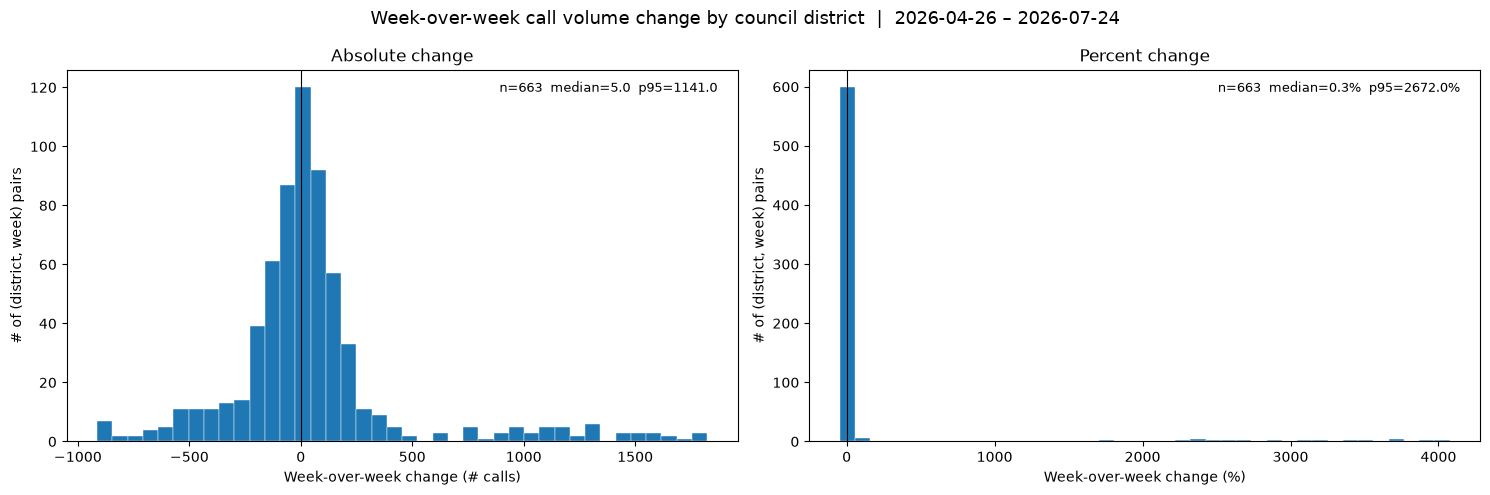

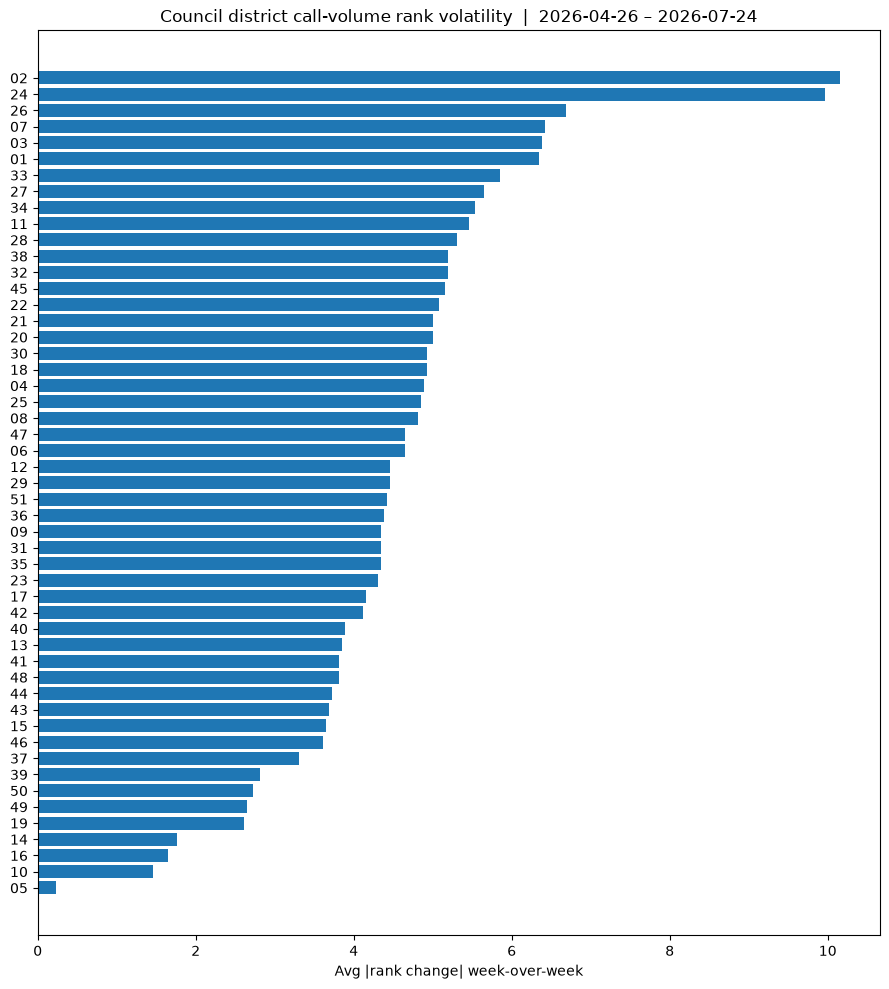

In [8]:
district_week = (
    df.dropna(subset=["council_district"])
    .groupby(["council_district", "year_week"])
    .size()
    .reset_index(name="count")
)
district_week_wide = district_week.pivot(index="council_district", columns="year_week", values="count").fillna(0)
district_week_wide = district_week_wide.loc[district_week_wide.sum(axis=1).sort_values(ascending=False).index]

wow_abs = district_week_wide.diff(axis=1)
wow_pct = district_week_wide.pct_change(axis=1).replace([np.inf, -np.inf], np.nan) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Week-over-week call volume change by council district  |  {date_range}", fontsize=13)

ax = axes[0]
vals = wow_abs.values.flatten()
vals = vals[~np.isnan(vals)]
bins = np.linspace(np.percentile(vals, 1), np.percentile(vals, 99), 41)
ax.hist(vals, bins=bins, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Week-over-week change (# calls)")
ax.set_ylabel("# of (district, week) pairs")
ax.set_title("Absolute change")
ax.annotate(
    f"n={len(vals):,}  median={np.median(vals):.1f}  p95={np.percentile(vals, 95):.1f}",
    xy=(0.97, 0.97), xycoords="axes fraction", ha="right", va="top", fontsize=9,
)

ax = axes[1]
vals = wow_pct.values.flatten()
vals = vals[~np.isnan(vals)]
bins = np.linspace(np.percentile(vals, 1), np.percentile(vals, 99), 41)
ax.hist(vals, bins=bins, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Week-over-week change (%)")
ax.set_ylabel("# of (district, week) pairs")
ax.set_title("Percent change")
ax.annotate(
    f"n={len(vals):,}  median={np.median(vals):.1f}%  p95={np.percentile(vals, 95):.1f}%",
    xy=(0.97, 0.97), xycoords="axes fraction", ha="right", va="top", fontsize=9,
)

plt.tight_layout()
plt.show()

district_rank = district_week_wide.rank(axis=0, ascending=False)
rank_change = district_rank.diff(axis=1).abs()
avg_rank_change = rank_change.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(avg_rank_change.index[::-1].astype(str), avg_rank_change.values[::-1])
ax.set_xlabel("Avg |rank change| week-over-week")
ax.set_title(f"Council district call-volume rank volatility  |  {date_range}")
plt.tight_layout()
plt.show()

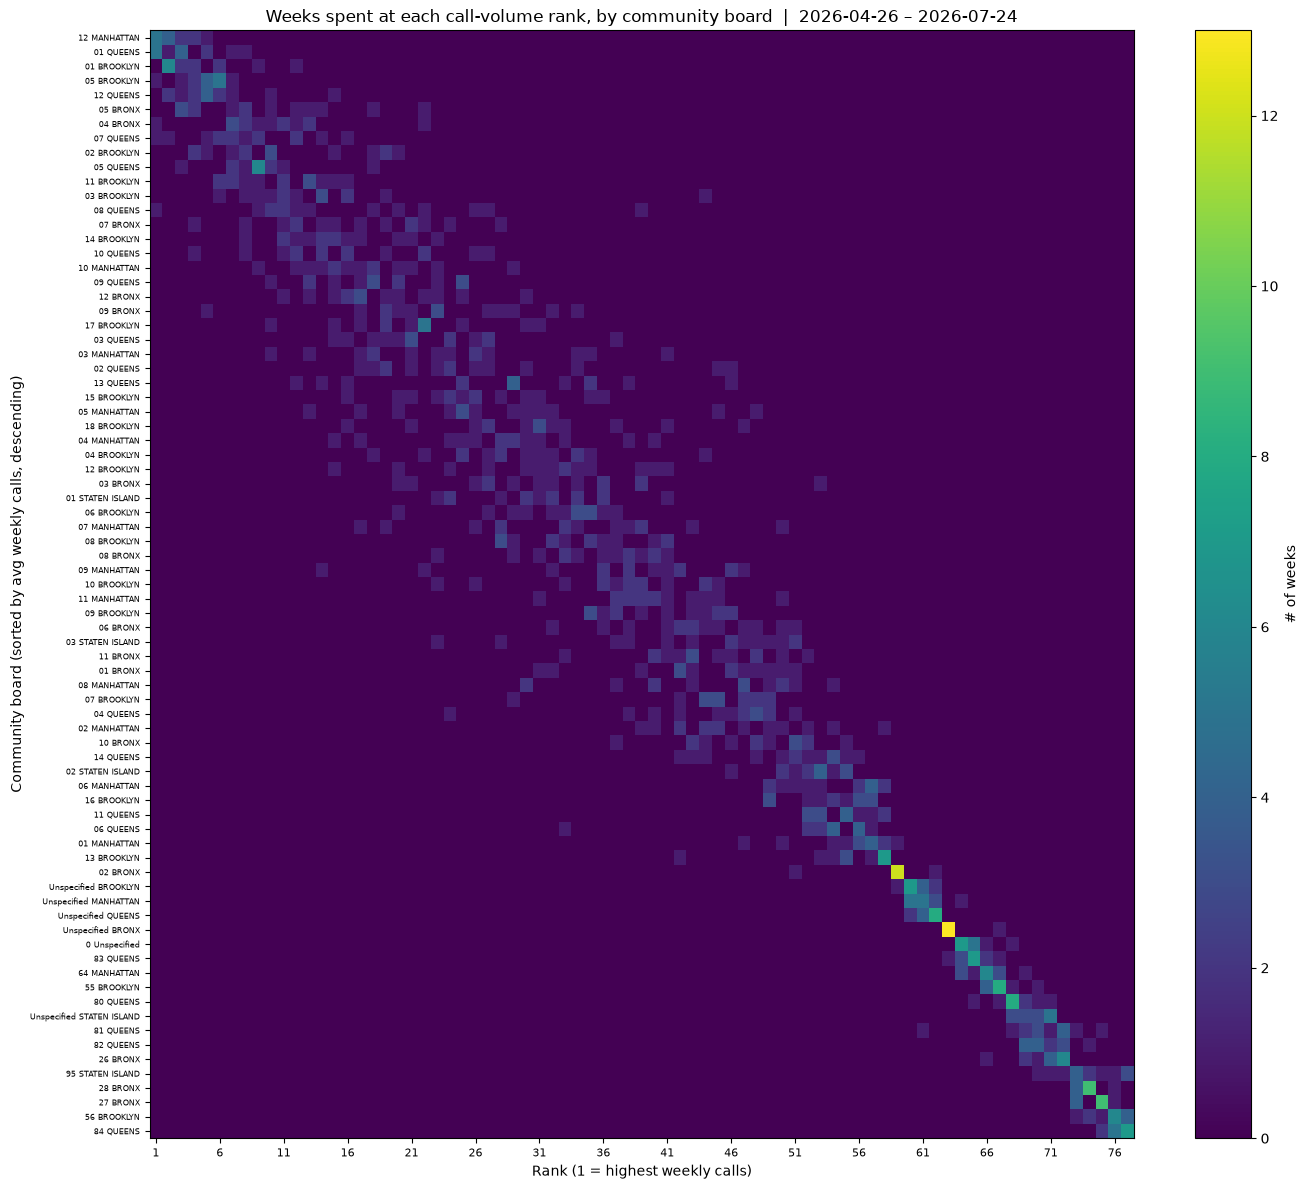

In [9]:
board_week = (
    df.dropna(subset=["community_board"])
    .groupby(["community_board", "year_week"])
    .size()
    .reset_index(name="count")
)
board_week_wide = board_week.pivot(index="community_board", columns="year_week", values="count").fillna(0)

avg_weekly = board_week_wide.mean(axis=1).sort_values(ascending=False)
board_week_wide = board_week_wide.loc[avg_weekly.index]

board_rank = board_week_wide.rank(axis=0, ascending=False, method="first")

n_boards = len(board_week_wide)
rank_counts = pd.DataFrame(0, index=board_week_wide.index, columns=range(1, n_boards + 1))
for board in board_week_wide.index:
    for rank, n in board_rank.loc[board].value_counts().items():
        rank_counts.loc[board, int(rank)] = n

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(rank_counts.values, aspect="auto", cmap="viridis")
ax.set_yticks(range(n_boards))
ax.set_yticklabels(rank_counts.index, fontsize=6)
ax.set_xticks(range(0, n_boards, 5))
ax.set_xticklabels(range(1, n_boards + 1, 5), fontsize=8)
ax.set_xlabel("Rank (1 = highest weekly calls)")
ax.set_ylabel("Community board (sorted by avg weekly calls, descending)")
ax.set_title(f"Weeks spent at each call-volume rank, by community board  |  {date_range}")
plt.colorbar(im, ax=ax, label="# of weeks")
plt.tight_layout()
plt.show()